# Tabular Pipeline — Aeolus Flight Delay Project

This notebook builds and validates the full tabular pipeline for flight delay prediction on a **synthetic dataset that replicates the exact schema of Aeolus** (Xu et al., 2025). It exists so that data preprocessing, feature engineering, model training, and evaluation can all be developed and tested *before* the real cleaned dataset is available from the teammate handling data preparation.

**How to use this now:** run every cell in order — it works immediately on the synthetic data, and every intermediate result (splits, features, metrics) is fully inspectable.

**How to switch to real data later:** modify **only** the `get_data()` function in Section 2. Nothing else in this notebook needs to change, as long as the real dataset's columns match the schema defined in Section 1.

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import psutil

In [2]:
mem = psutil.virtual_memory()
print(f"Total RAM: {mem.total / 1024**3:.1f} GB")
print(f"Available RAM: {mem.available / 1024**3:.1f} GB")

Total RAM: 15.4 GB
Available RAM: 10.9 GB


## 1. Reference schema (Aeolus, Table 9 of the paper)

This defines the exact set of columns the real dataset must provide: 8 categorical fields (carrier, flight number, date components, origin/destination airport codes), 14 continuous fields (scheduled times, weather at origin/destination, geographic coordinates), and 2 target columns (departure and arrival delay in minutes).

**This is the single most important thing to align on with the teammate cleaning the data.** If the real dataset uses these exact column names (case-sensitive), plugging it in later takes one line of code. If the names differ, either ask them to match this schema, or rename the columns yourself with `df.rename(columns=...)` once the data arrives — don't rewrite the pipeline.

In [3]:
CATEGORICAL_COLS = [
    "OP_CARRIER", "OP_CARRIER_FL_NUM", "FL_YEAR", "FL_MONTH",
    "FL_DAY", "FL_WEEK", "ORIGIN_INDEX", "DEST_INDEX",
]
CONTINUOUS_COLS = [
    "CRS_DEP_TIME_MIN", "CRS_ARR_TIME_MIN", "CRS_ELAPSED_TIME", "FLIGHTS",
    "O_TEMP", "O_PRCP", "O_WSPD", "D_TEMP", "D_PRCP", "D_WSPD",
    "O_LATITUDE", "O_LONGITUDE", "D_LATITUDE", "D_LONGITUDE",
]
TARGET_COLS = ["DEP_DELAY", "ARR_DELAY"]


## 2. Data loading

### Using it now (synthetic data)
The function below generates **fake but internally consistent** data: valid calendar dates, airports with fixed and consistent coordinates, and delays that are correlated with weather, rush hours, and season, following a right-skewed distribution similar to real flight delay data (see Figure 4 of the Aeolus paper). This exists purely to build and stress-test the pipeline before real data is ready — the numbers themselves have no real-world meaning.

### Switching to real data (when ready)
Replace the body of `get_data()` with:
```python
def get_data():
    return pd.read_parquet("path/to/real_dataset.parquet")
```
Nothing else needs to change, provided the columns match the schema from Section 1.

In [4]:
import pyarrow.parquet as pq
import os

path = "/home/sara/NeuralNetwork&DeepLearning/Flight-Delay-Forecasting/aeolus_tabular_2022_2024.parquet"
pf = pq.ParquetFile(path)
print("Total rows:", pf.metadata.num_rows)
print("Columns:", pf.metadata.num_columns)
print("Disk size (MB):", os.path.getsize(path) / 1024**2)

Total rows: 19341439
Columns: 23
Disk size (MB): 205.09546756744385


In [5]:
def generate_mock_data(n_rows: int = 200_000, seed: int = 42) -> pd.DataFrame:
    """Generated n_rows of fake data with same schema as Aeolus."""
    rng = np.random.default_rng(seed)

    # 40 fake aeroports with plausible coordinates
    n_airports = 40
    airport_codes = [f"A{str(i).zfill(3)}" for i in range(n_airports)]
    airport_lat = rng.uniform(25, 48, n_airports)
    airport_lon = rng.uniform(-122, -71, n_airports)
    airport_coord = {c: (la, lo) for c, la, lo in zip(airport_codes, airport_lat, airport_lon)}

    # 15 fake companies
    carriers = [f"C{str(i).zfill(2)}" for i in range(15)]

    # random dates between 2022-01-01 and 2024-12-31   
    date_range = pd.date_range("2022-01-01", "2024-12-31", freq="D")
    dates = pd.to_datetime(rng.choice(date_range, size=n_rows))

    #  origin/destination (different between them) 
    origin = rng.choice(airport_codes, size=n_rows)
    dest = np.array([rng.choice([c for c in airport_codes if c != o]) for o in origin])

    o_lat = np.array([airport_coord[c][0] for c in origin])
    o_lon = np.array([airport_coord[c][1] for c in origin])
    d_lat = np.array([airport_coord[c][0] for c in dest])
    d_lon = np.array([airport_coord[c][1] for c in dest])

    # scheduled times
    crs_dep_time_min = rng.integers(0, 1440, n_rows)
    crs_elapsed_time = rng.integers(40, 360, n_rows)
    crs_arr_time_min = (crs_dep_time_min + crs_elapsed_time) % 1440

    # synthetic weather data with month-based seasonality   
    month = dates.month.values
    seasonal_temp = 15 + 15 * np.sin((month - 3) / 12 * 2 * np.pi)
    o_temp = seasonal_temp + rng.normal(0, 8, n_rows)
    d_temp = seasonal_temp + rng.normal(0, 8, n_rows)
    o_prcp = rng.exponential(0.05, n_rows)
    d_prcp = rng.exponential(0.05, n_rows)
    o_wspd = rng.gamma(2, 4, n_rows)
    d_wspd = rng.gamma(2, 4, n_rows)

    flights = np.ones(n_rows, dtype=int)
    fl_num = rng.integers(100, 9999, n_rows)
    carrier = rng.choice(carriers, size=n_rows)

    # delay generation: base + weather + peak hour
    peak_hour_effect = np.where(
        (crs_dep_time_min % 1440 > 6 * 60) & (crs_dep_time_min % 1440 < 9 * 60), 6, 0
    ) + np.where(
        (crs_dep_time_min % 1440 > 16 * 60) & (crs_dep_time_min % 1440 < 20 * 60), 8, 0
    )
    weather_effect = 0.8 * o_prcp * 60 + 0.3 * o_wspd
    base_noise = rng.gumbel(loc=-3, scale=9, size=n_rows)  # right-skewed as in real data

    dep_delay = base_noise + peak_hour_effect + weather_effect
    arr_delay = dep_delay + rng.normal(0, 6, n_rows) - 0.05 * crs_elapsed_time

    df = pd.DataFrame({
        "OP_CARRIER": carrier,
        "OP_CARRIER_FL_NUM": fl_num,
        "FL_YEAR": dates.year.values,
        "FL_MONTH": dates.month.values,
        "FL_DAY": dates.day.values,
        "FL_WEEK": dates.isocalendar().week.values,
        "ORIGIN_INDEX": origin,
        "DEST_INDEX": dest,
        "CRS_DEP_TIME_MIN": crs_dep_time_min,
        "CRS_ARR_TIME_MIN": crs_arr_time_min,
        "CRS_ELAPSED_TIME": crs_elapsed_time,
        "FLIGHTS": flights,
        "O_TEMP": o_temp, "O_PRCP": o_prcp, "O_WSPD": o_wspd,
        "D_TEMP": d_temp, "D_PRCP": d_prcp, "D_WSPD": d_wspd,
        "O_LATITUDE": o_lat, "O_LONGITUDE": o_lon,
        "D_LATITUDE": d_lat, "D_LONGITUDE": d_lon,
        "DEP_DELAY": dep_delay,
        "ARR_DELAY": arr_delay,
        "_FLIGHT_DATE": dates,
    })
    return df.sort_values("_FLIGHT_DATE").reset_index(drop=True)





def get_data(sample_frac: float = 0.1) -> pd.DataFrame:
    """Read the parquet file in chunks (row groups) and sample each chunk during
    the reading process, instead of loading the entire file into RAM and then calling .sample().
    This is necessary because the complete dataset (multi-year) is too large to fit
    in memory on a student machine — see Section 3 of the project plan (RAM limitations on Colab free / laptop).
"""
    import pyarrow.parquet as pq
    rng = np.random.default_rng(42)

    path = "/home/sara/NeuralNetwork&DeepLearning/Flight-Delay-Forecasting/aeolus_tabular_2022_2024.parquet"
    pf = pq.ParquetFile(path)
    chunks = []
    for batch in pf.iter_batches(batch_size=200_000):
        chunk = batch.to_pandas()
        sampled = chunk.sample(frac=sample_frac, random_state=rng.integers(0, 1_000_000))
        chunks.append(sampled)
    df = pd.concat(chunks, ignore_index=True)

    # Timedelta -> minutes float
    for col in ["ARR_DELAY", "DEP_DELAY", "CRS_ELAPSED_TIME"]:
        df[col] = df[col].dt.total_seconds() / 60

    # align the column names to your agreed schema
    df = df.rename(columns={
        "MONTH": "FL_MONTH", "DAY_OF_MONTH": "FL_DAY",
        "ORIGIN": "ORIGIN_INDEX", "DEST": "DEST_INDEX",
    })

    fl_date = pd.to_datetime(dict(year=df["FL_YEAR"], month=df["FL_MONTH"], day=df["FL_DAY"]))
    df["FL_WEEK"] = fl_date.dt.isocalendar().week.astype(int)

    return df


df = get_data(sample_frac=1)  
print(df.shape)


def optimize_dtypes(df):
    """Riduce drasticamente la memoria: category per le stringhe ripetute
    (compagnia, aeroporti), int32/float32 al posto di int64/float64 —
    nel test misurato una riduzione del 74% di memoria."""
    for col in CATEGORICAL_COLS:
        if col in df.columns and df[col].dtype == object:
            df[col] = df[col].astype("category")
    for col in df.select_dtypes(include="int64").columns:
        df[col] = df[col].astype("int32")
    for col in df.select_dtypes(include="float64").columns:
        df[col] = df[col].astype("float32")
    return df

df = optimize_dtypes(df)
print(f"Memory after optimization: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

df.head()


(19341439, 24)
Memory after optimization: 1641.7 MB


,DEP_DELAY,ARR_DELAY,OP_CARRIER,OP_CARRIER_FL_NUM,FL_YEAR,FL_MONTH,FL_DAY,ORIGIN_INDEX,DEST_INDEX,CRS_DEP_TIME_MIN,...,O_PRCP,O_WSPD,D_TEMP,D_PRCP,D_WSPD,O_LATITUDE,O_LONGITUDE,D_LATITUDE,D_LONGITUDE,FL_WEEK
0,-7.0,-19.0,9E,5018,2022,6,6,CLE,JFK,1110,...,0.0,29.500000,23.299999,0.0,27.700001,41.410889,-81.849403,40.639751,-73.778931,23
1,-10.0,-22.0,9E,5293,2022,1,18,CLT,JFK,1199,...,0.0,0.000000,1.100000,0.0,38.900002,35.214008,-80.943130,40.639751,-73.778931,3
2,-2.0,12.0,OO,3106,2022,3,22,ORD,CID,915,...,1.0,27.700001,9.400000,0.0,29.500000,41.979599,-87.904457,41.884590,-91.710869,12
3,-1.0,20.0,YX,4794,2022,6,26,ORD,SYR,910,...,0.0,22.299999,32.799999,0.0,16.600000,41.979599,-87.904457,43.111191,-76.106308,25
4,-6.0,-18.0,MQ,3537,2022,12,16,DFW,CID,640,...,0.0,16.600000,-6.100000,0.0,29.500000,32.895950,-97.037201,41.884590,-91.710869,50


In [6]:
print(f"RSS memory process: {psutil.Process().memory_info().rss/1024**2:.0f} MB")

RSS memory process: 2634 MB


### 2b. Dataset validation

Before running the real dataset through this pipeline, it's worth checking it actually matches what the pipeline expects — wrong column names, unexpected missing values, or out-of-range coordinates are much easier to catch here than three cells later inside a cryptic LightGBM error. This function is tested below on both a clean and a deliberately broken version of the mock data, to confirm it catches real issues.


In [ ]:
def validate_dataset(df: pd.DataFrame, verbose: bool = True) -> dict:
    """Checks the dataset against the expected Aeolus schema before running
    the rest of the pipeline on it. Returns a report dict; does not modify df."""
    report = {"errors": [], "warnings": [], "info": []}

    expected_cols = CATEGORICAL_COLS + CONTINUOUS_COLS + TARGET_COLS
    missing_cols = [c for c in expected_cols if c not in df.columns]
    extra_cols = [c for c in df.columns if c not in expected_cols and c != "_FLIGHT_DATE"]
    if missing_cols:
        report["errors"].append(f"Missing expected columns: {missing_cols}")
    if extra_cols:
        report["warnings"].append(f"Extra columns not in schema (fine if intentional): {extra_cols}")

    present_cols = [c for c in expected_cols if c in df.columns]

    na_counts = df[present_cols].isna().sum()
    na_cols = na_counts[na_counts > 0]
    if len(na_cols) > 0:
        pct = (na_cols / len(df) * 100).round(2)
        report["warnings"].append(
            "Missing values found:\n" + pd.concat([na_cols, pct], axis=1, keys=["n_missing", "pct"]).to_string()
        )

    n_dup = df.duplicated().sum()
    if n_dup > 0:
        report["warnings"].append(f"{n_dup} duplicate rows found ({n_dup/len(df)*100:.2f}%)")

    range_checks = {
        "O_LATITUDE": (-90, 90), "D_LATITUDE": (-90, 90),
        "O_LONGITUDE": (-180, 180), "D_LONGITUDE": (-180, 180),
        "CRS_DEP_TIME_MIN": (0, 1439), "CRS_ARR_TIME_MIN": (0, 1439),
        "CRS_ELAPSED_TIME": (0, 24 * 60),
        "O_PRCP": (0, None), "D_PRCP": (0, None),
        "O_WSPD": (0, None), "D_WSPD": (0, None),
    }
    for col, (lo, hi) in range_checks.items():
        if col not in df.columns:
            continue
        n_bad = len(df[df[col] < lo]) + (len(df[df[col] > hi]) if hi is not None else 0)
        if n_bad > 0:
            report["warnings"].append(f"{col}: {n_bad} rows outside plausible range [{lo}, {hi}]")

    for col in TARGET_COLS:
        if col not in df.columns:
            continue
        extreme = df[(df[col] < -60) | (df[col] > 1440)]
        if len(extreme) > 0:
            report["warnings"].append(f"{col}: {len(extreme)} extreme values (< -60 min or > 1440 min) — worth checking, not necessarily errors")

    for col in CATEGORICAL_COLS:
        if col in df.columns:
            report["info"].append(f"{col}: {df[col].nunique()} unique values")

    report["info"].append(f"Dataset shape: {df.shape}")

    if verbose:
        print("=== VALIDATION REPORT ===")
        print("\n❌ ERRORS (blocking):" if report["errors"] else "\n✅ No blocking errors")
        for e in report["errors"]:
            print(" -", e)
        if report["warnings"]:
            print("\n⚠️  WARNINGS (worth checking):")
            for w in report["warnings"]:
                print(" -", w)
        print("\nℹ️  INFO:")
        for i in report["info"]:
            print(" -", i)

    return report


# Run it on the currently loaded dataset (mock now, real data later — nothing else to change)
validation_report = validate_dataset(df)

=== VALIDATION REPORT ===

✅ No blocking errors

⚠️  WARNINGS (worth checking):
 - Missing values found:
        n_missing   pct
O_TEMP       1554  0.01
O_PRCP       1554  0.01
O_WSPD       1554  0.01
 - CRS_ELAPSED_TIME: 5 rows outside plausible range [0, 1440]
 - DEP_DELAY: 1360 extreme values (< -60 min or > 1440 min) — worth checking, not necessarily errors
 - ARR_DELAY: 4349 extreme values (< -60 min or > 1440 min) — worth checking, not necessarily errors

ℹ️  INFO:
 - OP_CARRIER: 17 unique values
 - OP_CARRIER_FL_NUM: 6989 unique values
 - FL_YEAR: 3 unique values
 - FL_MONTH: 12 unique values
 - FL_DAY: 31 unique values
 - FL_WEEK: 52 unique values
 - ORIGIN_INDEX: 316 unique values
 - DEST_INDEX: 315 unique values
 - Dataset shape: (19341439, 24)


: 

## 3. Feature engineering

Adds derived features on top of the 22 native Aeolus columns, inspired by the literature review for this project:

- **Cyclical time features** (sine/cosine of hour-of-day, day-of-week, month): preserves continuity around midnight/year-end, which raw integers or one-hot encoding would break.
- **Great-circle distance**: computed from the origin/destination lat/lon coordinates already present in Aeolus.
- **Airport congestion proxy**: number of flights scheduled from the same origin airport, on the same day, within the same 2-hour window. This is based only on *scheduled* times, so it introduces no leakage and is safe to compute before the temporal split.
- **Binary delay target**: flags a flight as delayed if it exceeds the 15-minute threshold, matching Aeolus's own official benchmark for direct comparability.

In [ ]:
def add_cyclic_time_features(df: pd.DataFrame) -> pd.DataFrame:
    """Hour of day and day of week as sine/cosine instead of raw integers:
    preserves continuity (23:59 close to 00:00)."""
    df = df.copy()
    minutes_in_day = 24 * 60

    df["dep_hour_sin"] = np.sin(2 * np.pi * df["CRS_DEP_TIME_MIN"] / minutes_in_day)
    df["dep_hour_cos"] = np.cos(2 * np.pi * df["CRS_DEP_TIME_MIN"] / minutes_in_day)
    df["arr_hour_sin"] = np.sin(2 * np.pi * df["CRS_ARR_TIME_MIN"] / minutes_in_day)
    df["arr_hour_cos"] = np.cos(2 * np.pi * df["CRS_ARR_TIME_MIN"] / minutes_in_day)

    date = pd.to_datetime(dict(year=df["FL_YEAR"], month=df["FL_MONTH"], day=df["FL_DAY"]))
    dow = date.dt.dayofweek
    df["dow_sin"] = np.sin(2 * np.pi * dow / 7)
    df["dow_cos"] = np.cos(2 * np.pi * dow / 7)
    df["month_sin"] = np.sin(2 * np.pi * df["FL_MONTH"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["FL_MONTH"] / 12)
    return df


def add_great_circle_distance(df: pd.DataFrame) -> pd.DataFrame:
    """Great-circle distance (Haversine, km) between origin and destination."""
    df = df.copy()
    R = 6371.0
    lat1, lon1 = np.radians(df["O_LATITUDE"]), np.radians(df["O_LONGITUDE"])
    lat2, lon2 = np.radians(df["D_LATITUDE"]), np.radians(df["D_LONGITUDE"])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    df["great_circle_km"] = R * 2 * np.arcsin(np.sqrt(a))
    return df


def add_airport_congestion(df: pd.DataFrame) -> pd.DataFrame:
    """Congestion proxy: number of flights scheduled from the same origin
    airport, on the same day, within the same 2-hour window. Based only on
    SCHEDULED times -> no leakage, safe to compute even before the temporal
    split."""   
    df = df.copy()
    df["dep_hour_bucket"] = (df["CRS_DEP_TIME_MIN"] // 120).astype(int)
    congestion = (
        df.groupby(["ORIGIN_INDEX", "FL_YEAR", "FL_MONTH", "FL_DAY", "dep_hour_bucket"])
        .size().rename("origin_congestion_2h").reset_index()
    )
    df = df.merge(congestion, on=["ORIGIN_INDEX", "FL_YEAR", "FL_MONTH", "FL_DAY", "dep_hour_bucket"], how="left")
    return df


def add_binary_target(df: pd.DataFrame, threshold: int = 15) -> pd.DataFrame:
    """Binary target aligned with the official Aeolus benchmark (15-min threshold)."""
    df = df.copy()
    df["ARR_DELAY_BIN"] = (df["ARR_DELAY"] > threshold).astype(int)
    df["DEP_DELAY_BIN"] = (df["DEP_DELAY"] > threshold).astype(int)
    return df
# Here only delays are treated as anomalies. If early arrivals/departures
# should also be treated as anomalies, a negative threshold could be used
# (e.g. -15 min). In that case, the function would become:
#
#def add_binary_target(df: pd.DataFrame, threshold: int = 15, include_early: bool = False) -> pd.DataFrame:
 #   df = df.copy()
  #  if include_early:
   #     # as in the official repo Aeolus: take the absolute value of the delay, so both early and late flights are considered anomalies
    #    df["ARR_DELAY_BIN"] = (df["ARR_DELAY"].abs() > threshold).astype(int)
     #   df["DEP_DELAY_BIN"] = (df["DEP_DELAY"].abs() > threshold).astype(int)
 #   else:
  #      df["ARR_DELAY_BIN"] = (df["ARR_DELAY"] > threshold).astype(int)
   #     df["DEP_DELAY_BIN"] = (df["DEP_DELAY"] > threshold).astype(int)
    #return df

def add_all_features(df: pd.DataFrame, delay_threshold: int = 15) -> pd.DataFrame:
    """Versione memory-safe: una sola copia iniziale, poi tutte le feature
    vengono aggiunte in-place sullo stesso oggetto, invece di incatenare
    funzioni che fanno ciascuna un .copy() completo del dataframe."""
    df = df.copy()  
    
    minutes_in_day = 24 * 60
    df["dep_hour_sin"] = np.sin(2 * np.pi * df["CRS_DEP_TIME_MIN"] / minutes_in_day)
    df["dep_hour_cos"] = np.cos(2 * np.pi * df["CRS_DEP_TIME_MIN"] / minutes_in_day)
    df["arr_hour_sin"] = np.sin(2 * np.pi * df["CRS_ARR_TIME_MIN"] / minutes_in_day)
    df["arr_hour_cos"] = np.cos(2 * np.pi * df["CRS_ARR_TIME_MIN"] / minutes_in_day)

    date = pd.to_datetime(dict(year=df["FL_YEAR"], month=df["FL_MONTH"], day=df["FL_DAY"]))
    dow = date.dt.dayofweek
    df["dow_sin"] = np.sin(2 * np.pi * dow / 7)
    df["dow_cos"] = np.cos(2 * np.pi * dow / 7)
    df["month_sin"] = np.sin(2 * np.pi * df["FL_MONTH"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["FL_MONTH"] / 12)
    del date, dow  
    R = 6371.0
    lat1, lon1 = np.radians(df["O_LATITUDE"]), np.radians(df["O_LONGITUDE"])
    lat2, lon2 = np.radians(df["D_LATITUDE"]), np.radians(df["D_LONGITUDE"])
    a = np.sin((lat2-lat1)/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin((lon2-lon1)/2)**2
    df["great_circle_km"] = R * 2 * np.arcsin(np.sqrt(a))
    del lat1, lon1, lat2, lon2, a

    df["dep_hour_bucket"] = (df["CRS_DEP_TIME_MIN"] // 120).astype("int8")
    congestion = (
        df.groupby(["ORIGIN_INDEX", "FL_YEAR", "FL_MONTH", "FL_DAY", "dep_hour_bucket"], observed=True)
        .size().rename("origin_congestion_2h").reset_index()
    )
    df = df.merge(congestion, on=["ORIGIN_INDEX", "FL_YEAR", "FL_MONTH", "FL_DAY", "dep_hour_bucket"], how="left")
    del congestion

    df["ARR_DELAY_BIN"] = (df["ARR_DELAY"] > delay_threshold).astype("int8")
    df["DEP_DELAY_BIN"] = (df["DEP_DELAY"] > delay_threshold).astype("int8")

    return df


import gc
df = add_all_features(df, delay_threshold=15)
gc.collect() 

print(df.shape)
print("\nClass balance (ARR_DELAY_BIN):")
print(df["ARR_DELAY_BIN"].value_counts(normalize=True))


In [ ]:
print(f"RSS memory process: {psutil.Process().memory_info().rss/1024**2:.0f} MB")

RSS memoria processo: 5415 MB


## 4. Temporal split (60/20/20, never random)

Splits the dataset chronologically by day into train (60%), validation (20%), and test (20%) sets, preserving time order.

**Why this matters:** Xu et al. (2025) show empirically that a random split inflates AUC by +0.057 on average compared to a temporal split, because it leaks future information into training. A random split would make the model look better than it actually is on unseen, future flights — which is exactly the real-world use case we care about.

In [ ]:
import gc

def temporal_split(df: pd.DataFrame, date_col: str = "_FLIGHT_DATE"):
    if date_col not in df.columns:
        df[date_col] = pd.to_datetime(dict(year=df["FL_YEAR"], month=df["FL_MONTH"], day=df["FL_DAY"]))

    df.sort_values(date_col, inplace=True)
    df.reset_index(drop=True, inplace=True)

    n = len(df)
    train_end, val_end = int(n * 0.6), int(n * 0.8)

    train = df.iloc[:train_end].copy()
    val = df.iloc[train_end:val_end].copy()
    test = df.iloc[val_end:].copy()

    print(f"Train: {train[date_col].min().date()} -> {train[date_col].max().date()} ({len(train)} rows)")
    print(f"Val:   {val[date_col].min().date()} -> {val[date_col].max().date()} ({len(val)} rows)")
    print(f"Test:  {test[date_col].min().date()} -> {test[date_col].max().date()} ({len(test)} rows)")

    return train, val, test


train, val, test = temporal_split(df)

del df
gc.collect()

Train: 2022-01-01 -> 2023-10-13 (11604863 righe)
Val:   2023-10-13 -> 2024-06-12 (3868288 righe)
Test:  2024-06-12 -> 2024-12-31 (3868288 righe)


0

In [ ]:
print(f"RSS memory process: {psutil.Process().memory_info().rss/1024**2:.0f} MB")

RSS memoria processo: 5595 MB


### 4b. Outlier removal 

In [ ]:
train_raw, val_raw, test_raw = train.copy(), val.copy(), test.copy()

In [ ]:
#  Outlier removal (TRAIN ONLY — val/test stay untouched)
# nella repository Flmnny lo facevano in tutto dataset, ma questo introduce leakage. Meglio calcolare i bound solo sul train e poi applicarli a val/test.


def remove_outliers_train_only(train_df, column, lower=0.01, upper=0.99):
    """Remove extreme delays ONLY from the training set, to stabilize
    learning. Val and test remain untouched: they should represent the
    real distribution that the model will encounter in evaluation/production,
    including extreme cases."""
    lower_bound = train_df[column].quantile(lower)
    upper_bound = train_df[column].quantile(upper)
    print(f"{column}: bound = [{lower_bound:.1f}, {upper_bound:.1f}] min (computed on train)")

    train_clean = train_df[(train_df[column] >= lower_bound) & (train_df[column] <= upper_bound)]
    removed = len(train_df) - len(train_clean)
    print(f"train: removed {removed} flights ({removed/len(train_df)*100:.2f}%)")
    print("val/test: not modified")

    return train_clean, lower_bound, upper_bound


train, lo, hi = remove_outliers_train_only(train, "ARR_DELAY")
# val set and test set remain the originals

ARR_DELAY: bound = [-36.0, 206.0] min (computed on train)
train: removed 215849 flights (1.86%)
val/test: not modified


### 4c. Class balance check (before vs after outlier removal)

Removing extreme delays could plausibly shift the class balance of the binary target, since delays follow a right-skewed distribution — there are more extreme outliers on the "delayed" side than on the "on-time" side. This section checks that directly with numbers and plots, rather than assuming it.

In [14]:
def class_balance_report(splits: dict, target_col: str, label: str = ""):
    """Prints a class balance table for each split (train/val/test)."""
    print(f"\n=== Class balance — {target_col} {label} ===")
    rows = []
    for split_name, split_df in splits.items():
        counts = split_df[target_col].value_counts().sort_index()
        pct = split_df[target_col].value_counts(normalize=True).sort_index() * 100
        rows.append({
            "split": split_name, "n_total": len(split_df),
            "n_on_time": counts.get(0, 0), "n_delayed": counts.get(1, 0),
            "%_delayed": round(pct.get(1, 0), 2),
        })
    report = pd.DataFrame(rows)
    print(report.to_string(index=False))
    return report


# Report BEFORE outlier removal — run this on the splits produced by Section 4,
# saved under different names so they survive the outlier removal step below
report_before = class_balance_report(
    {"train": train_raw, "val": val_raw, "test": test_raw}, "ARR_DELAY_BIN", label="(before outlier removal)"
)

# Outlier removal bounds (reuses the same logic as Section 4bis)
lo = train_raw["ARR_DELAY"].quantile(0.01)
hi = train_raw["ARR_DELAY"].quantile(0.99)
print(f"\nBounds computed on train: [{lo:.1f}, {hi:.1f}] minutes")

report_after = class_balance_report(
    {"train": train, "val": val, "test": test}, "ARR_DELAY_BIN", label="(after outlier removal)"
)

# Direct comparison
comparison = report_before[["split", "%_delayed"]].merge(
    report_after[["split", "%_delayed"]], on="split", suffixes=("_before", "_after")
)
comparison["difference"] = (comparison["%_delayed_after"] - comparison["%_delayed_before"]).round(2)
print("\n=== Direct comparison: % delayed flights, before vs after ===")
print(comparison.to_string(index=False))


=== Class balance — ARR_DELAY_BIN (before outlier removal) ===
split  n_total  n_on_time  n_delayed  %_delayed
train 11604863    9190829    2414034      20.80
  val  3868288    3153000     715288      18.49
 test  3868288    3112280     756008      19.54

Bounds computed on train: [-36.0, 206.0] minutes

=== Class balance — ARR_DELAY_BIN (after outlier removal) ===
split  n_total  n_on_time  n_delayed  %_delayed
train 11389014    9090218    2298796      20.18
  val  3868288    3153000     715288      18.49
 test  3868288    3112280     756008      19.54

=== Direct comparison: % delayed flights, before vs after ===
split  %_delayed_before  %_delayed_after  difference
train             20.80            20.18       -0.62
  val             18.49            18.49        0.00
 test             19.54            19.54        0.00


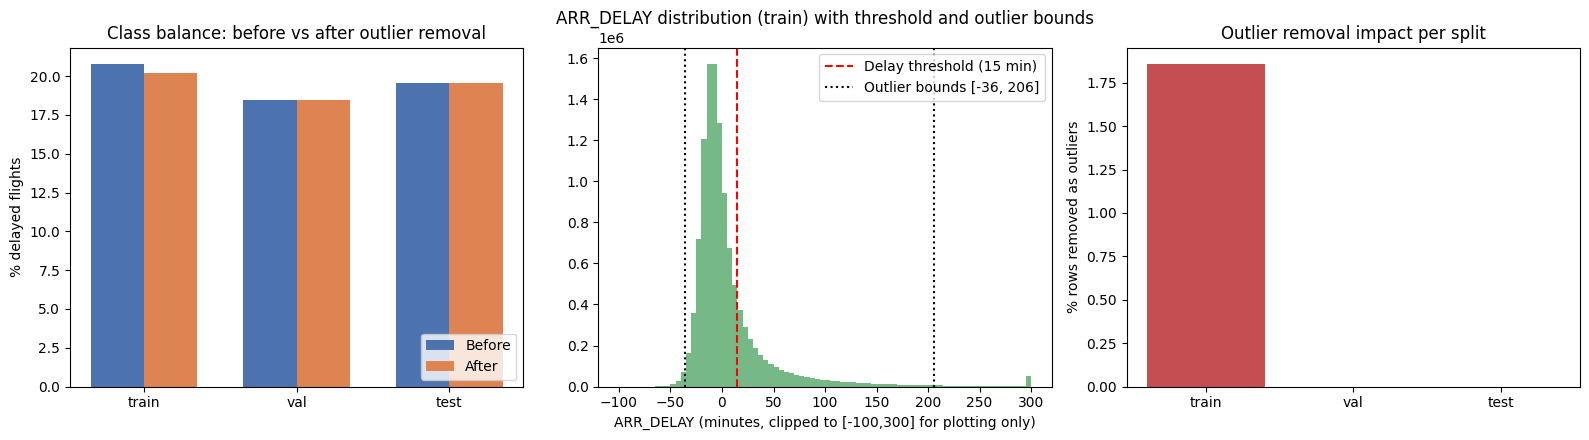

In [15]:
# Visualizations

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

x = np.arange(len(report_before))
width = 0.35
axes[0].bar(x - width/2, report_before["%_delayed"], width, label="Before", color="#4C72B0")
axes[0].bar(x + width/2, report_after["%_delayed"], width, label="After", color="#DD8452")
axes[0].set_xticks(x)
axes[0].set_xticklabels(report_before["split"])
axes[0].set_ylabel("% delayed flights")
axes[0].set_title("Class balance: before vs after outlier removal")
axes[0].legend(loc="lower right")

axes[1].hist(train_raw["ARR_DELAY"].clip(-100, 300), bins=80, color="#55A868", alpha=0.8)
axes[1].axvline(15, color="red", linestyle="--", label="Delay threshold (15 min)")
axes[1].axvline(lo, color="black", linestyle=":", label=f"Outlier bounds [{lo:.0f}, {hi:.0f}]")
axes[1].axvline(hi, color="black", linestyle=":")
axes[1].set_xlabel("ARR_DELAY (minutes, clipped to [-100,300] for plotting only)")
axes[1].set_title("ARR_DELAY distribution (train) with threshold and outlier bounds")
axes[1].legend()

removed_pct = [
    (len(train_raw) - len(train)) / len(train_raw) * 100,
    (len(val_raw) - len(val)) / len(val_raw) * 100,
    (len(test_raw) - len(test)) / len(test_raw) * 100,
]
axes[2].bar(["train", "val", "test"], removed_pct, color="#C44E52")
axes[2].set_ylabel("% rows removed as outliers")
axes[2].set_title("Outlier removal impact per split")

plt.tight_layout()
plt.show()

## 5. Categorical encoding (fit on train only)

Converts categorical columns (carrier, airport codes, etc.) into integer codes using label encoding. The encoder is **fit only on the training set**; any category seen in validation/test but not in training is mapped to a dedicated "unseen" value (-1) rather than crashing the pipeline. Fitting on the full dataset before the split would leak information from validation/test into training — the same leakage principle as the temporal split above, applied to categorical encoding instead of dates.

In [ ]:
def encode_categoricals(train, val, test, cat_cols):
    """Label encoding for categorical columns. The mapping is computed on the train set and applied to val/test. 
    Unseen categories in val/test are mapped to -1."""
    encoders = {}
    for col in cat_cols:
        le = LabelEncoder()
        le.fit(train[col].astype(str))
        mapping = {cls: i for i, cls in enumerate(le.classes_)}
        for split_df in (train, val, test):
            split_df[col] = split_df[col].astype(str).map(mapping).fillna(-1).astype("int32")  # int32 instead of int (=int64): half memory
        encoders[col] = mapping
    return train, val, test, encoders


cat_cols = CATEGORICAL_COLS
train, val, test, encoders = encode_categoricals(train, val, test, cat_cols)

target_col = "ARR_DELAY_BIN"
exclude_cols = {"ARR_DELAY", "DEP_DELAY", "ARR_DELAY_BIN", "DEP_DELAY_BIN", "_FLIGHT_DATE", "dep_hour_bucket"}
feature_cols = [c for c in train.columns if c not in exclude_cols]
print(f"Feature used ({len(feature_cols)}): {feature_cols}")


Feature used (32): ['OP_CARRIER', 'OP_CARRIER_FL_NUM', 'FL_YEAR', 'FL_MONTH', 'FL_DAY', 'ORIGIN_INDEX', 'DEST_INDEX', 'CRS_DEP_TIME_MIN', 'CRS_ARR_TIME_MIN', 'CRS_ELAPSED_TIME', 'FLIGHTS', 'O_TEMP', 'O_PRCP', 'O_WSPD', 'D_TEMP', 'D_PRCP', 'D_WSPD', 'O_LATITUDE', 'O_LONGITUDE', 'D_LATITUDE', 'D_LONGITUDE', 'FL_WEEK', 'dep_hour_sin', 'dep_hour_cos', 'arr_hour_sin', 'arr_hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'great_circle_km', 'origin_congestion_2h']


In [ ]:
print(f"RSS memory process: {psutil.Process().memory_info().rss/1024**2:.0f} MB")

RSS memoria processo: 9467 MB


In [ ]:
# Save the encoded splits to parquet for later use (e.g., training models)
train.to_parquet("train_encoded.parquet", index=False)
val.to_parquet("val_encoded.parquet", index=False)
test.to_parquet("test_encoded.parquet", index=False)